In [58]:
import pandas as pd
import numpy as np

In [59]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
import joblib
import pickle
import matplotlib.pyplot as plt
from xgboost import plot_importance

In [60]:
df = pd.read_csv('data/drom_archive_cleaned_2018-2025.csv')

In [61]:
# Пробег на год
df['mileage_per_year'] = df['Пробег'] / (2024 - df['Год'] + 1)
df['log_mileage'] = np.log1p(df['Пробег'])

# Мощность на литр двигателя
df['power_per_liter'] = df['Мощность'] / df['Объем двигателя']

In [62]:
categorical = ['Тип двигателя', 'Коробка передач', 'Привод', 'Поколение', 'Рестайлинг',
               'Тип кузова', 'Метка', 'Город']
numerical = ['mileage_per_year', 'log_mileage', 'power_per_liter', 'Мощность', 'Год']

In [63]:
preprocessor = ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), categorical), ('num', 'passthrough', numerical)], remainder='drop')

In [64]:
y = df['Цена']
X = df.drop('Цена', axis=1)

X_train = X[X['Год объявления'] <= 2023]
X_test = X[X['Год объявления'] >= 2024]

y_train = y[X['Год объявления'] <= 2023]
y_test = y[X['Год объявления'] >= 2024]

model = XGBRegressor(
        n_estimators=500,
        n_jobs=-1,
        random_state=42,
        eval_metric='rmse'
    )
pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', model)
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [65]:
feature_names = pipeline.named_steps["prep"].get_feature_names_out()

importances = pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("TOP 20 признаков:")
print(importance_df.head(20))


TOP 20 признаков:
                             feature  importance
3443                        num__Год    0.096745
3442                   num__Мощность    0.091555
65                   cat__Метка_lada    0.078838
35    cat__Тип кузова_джип/suv 5 дв.    0.038071
10              cat__Привод_передний    0.032402
32               cat__Рестайлинг_6.0    0.030763
68                  cat__Метка_lexus    0.025079
4          cat__Коробка передач_МКПП    0.024149
31               cat__Рестайлинг_5.0    0.023572
82                 cat__Метка_toyota    0.020877
0          cat__Тип двигателя_бензин    0.017796
76                cat__Метка_porsche    0.015466
6      cat__Коробка передач_редуктор    0.013959
33               cat__Рестайлинг_7.0    0.013298
64                    cat__Метка_kia    0.012118
72          cat__Метка_mercedes-benz    0.011091
47                cat__Метка_bentley    0.010876
58                  cat__Метка_haval    0.009724
3441            num__power_per_liter    0.009390
11

In [66]:
importance_df["feature_group"] = importance_df["feature"].apply(
    lambda x: x.split("__")[1].split("_")[0]
)

grouped_importance = (
    importance_df
    .groupby("feature_group")["importance"]
    .sum()
    .sort_values(ascending=False)
)

print("\nВажность исходных признаков:")
print(grouped_importance)


Важность исходных признаков:
feature_group
Метка              0.295251
Город              0.199454
Год                0.096745
Мощность           0.091555
Рестайлинг         0.083737
Тип кузова         0.070905
Коробка передач    0.046939
Поколение          0.044790
Привод             0.041243
Тип двигателя      0.017796
power              0.009390
mileage            0.001127
log                0.001068
Name: importance, dtype: float32


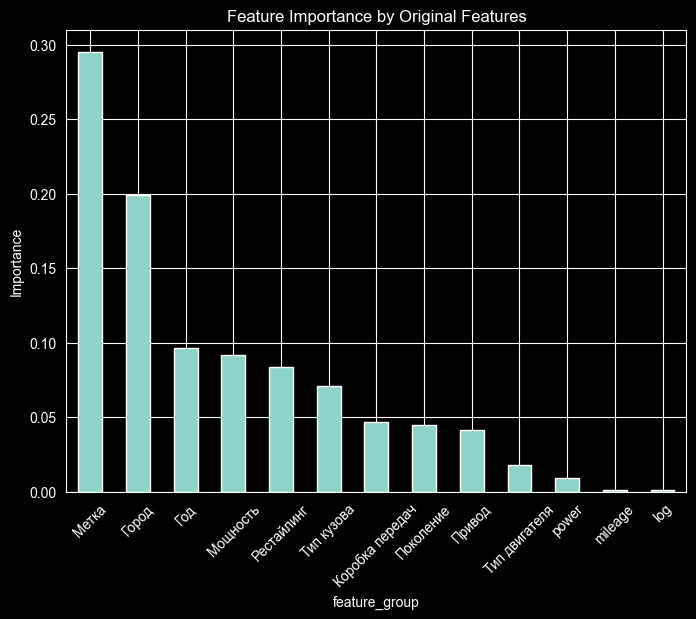

In [67]:
plt.figure(figsize=(8,6))
grouped_importance.plot(kind="bar")
plt.title("Feature Importance by Original Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

In [68]:
y_pred = model.predict(X_test)

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:Название машины: str, Тип двигателя: str, Коробка передач: str, Привод: str, Руль: str, Тип кузова: str, Метка: str, Город: str

In [ ]:
xg_mse = mean_squared_error(y_test, y_pred)
xg_rmse = np.sqrt(xg_mse)
xg_mae = mean_absolute_error(y_test, y_pred)
xg_r2 = r2_score(y_test, y_pred)

pd.options.display.float_format = '{:_.2f}'.format
pd.DataFrame({
    'Метод оценки': ['Среднеквадратическая ошибка (MSE)', 'Среднеквадратическая ошибка (RMSE)',
                     'Средняя абсолютная ошибка (MAE)', 'Коэффицент детерминации (R^2)'],
    'Результаты': [xg_mse, xg_rmse, xg_mae, xg_r2]
})